In [4]:
# ===== 标准库 =====
import os
import sys
import math
import pickle
import itertools
# ===== 科学计算 / 数据处理 =====
import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.stats import gaussian_kde
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter1d
# ===== 绘图相关 =====
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib import font_manager, rcParams
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import matplotlib.ticker as ticker
from matplotlib.ticker import FuncFormatter
import matplotlib.image as mpimg
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
# ===== 机器学习 / 聚类 =====
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram, cut_tree
import seaborn as sns
# ===== 空间统计 / 空间权重 =====
from libpysal import weights
from libpysal.weights import util, WSP
from esda import Moran_Local
from matplotlib.lines import Line2D

/home/wangtao/anaconda3/envs/Trajectron_veh/lib/python3.7/site-packages/libpysal/weights/util.py:23: UserWarning: geopandas not available. Some functionality will be disabled.
  warn("geopandas not available. Some functionality will be disabled.")


In [5]:
from mpl_toolkits.mplot3d import Axes3D  # 有些版本需要显式导入

In [6]:
# 添加 Trajectron++ 所在路径
sys.path.append('/home/wangtao/下载/Trajectron-ped-veh/Data_gen/trajectron')
sys.path.append('/home/wangtao/下载/Trajectron-ped-veh/Data_ana')
sys.path.append('/home/wangtao/下载/Trajectron-ped-veh/trajectron')
from analysis import risk_field_properties,risk_field_stats,bivariate_gaussian,gmm_overlap_score,load_pkl_by_timestep,replace_outliers_custom,compute_ttc_x,compute_ttc_y,adjust_ttc,add_tdtc,compute_acceleration,heading_rate,compute_act_row,conflict_score_from_mean_intersection

plt.rcParams.update({ 
    'font.family' : 'Liberation Serif',
    'font.size': 12,
    'axes.titlesize': 12,
    'axes.labelsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'mathtext.fontset': 'cm',
    'mathtext.rm': 'serif',
    # 隐藏上边框和刻度
    'axes.spines.top': True,
    # 保留其他边框和小刻度
    'axes.spines.right': True,
    'axes.spines.bottom': True,
    'axes.spines.left': True,
    'xtick.minor.visible': False,
    'ytick.minor.visible': False,
    # 刻度朝内
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    # 右侧和上侧的刻度也朝内
    'xtick.top': False,
    'ytick.right': False,
    # 关闭网格
    'axes.grid': False,})

In [7]:
location='TJ'

In [8]:
def data_pre(predic, true, history):   
    base_dir =f"/home/wangtao/下载/Trajectron-ped-veh/Data_ana/Data_gen/{location}"

    with open(os.path.join(base_dir, f"{predic}.pkl"), 'rb') as f:
        pre_full = pickle.load(f)

    with open(os.path.join(base_dir, f"{true}.pkl"), 'rb') as f:
        tru = pickle.load(f)

    with open(os.path.join(base_dir, f"{history}.pkl"), 'rb') as f:
        his = pickle.load(f)

    def key_to_str(k):
        # Trajectron Node: 有 type.name 和 id
        if hasattr(k, "type") and hasattr(k, "id") and hasattr(k.type, "name"):
            return f"{k.type.name}/{k.id}"  # id 会自动转成 str
        return str(k)
    pre_full = {
        key_to_str(outer_k): {key_to_str(inner_k): inner_v for inner_k, inner_v in outer_v.items()}
        for outer_k, outer_v in pre_full.items()}
    tru  = {
        key_to_str(outer_k): {key_to_str(inner_k): inner_v for inner_k, inner_v in outer_v.items()}
        for outer_k, outer_v in tru.items()}
    his  = {
        key_to_str(outer_k): {key_to_str(inner_k): inner_v for inner_k, inner_v in outer_v.items()}
        for outer_k, outer_v in his.items()}
    return pre_full,tru,his

In [9]:
base_path = f'/home/wangtao/下载/Trajectron-ped-veh/Data_ana/Data_gen/{location}'

In [10]:
def key_to_str(k):
    # Trajectron Node: 有 type.name 和 id
    if hasattr(k, "type") and hasattr(k, "id") and hasattr(k.type, "name"):
        return f"{k.type.name}/{k.id}"  # id 会自动转成 str
    return str(k)

def print_two_level_keys(pre_full):
    for outer_k, inner_dict in pre_full.items():
        print(str(outer_k))                      # 打印第一层键
        for inner_k in inner_dict.keys():
            print("   →", str(inner_k))         # 打印第二层键，缩进
#print_two_level_keys(pre_full)

def tra_data(time_step,agent_id):
    ts = str(time_step)
    # frame_list=list(pre_full.keys())
    # for node in tru[frame_list[time_step]].keys():
    #     print('e',int(f'{str(node.id )}'.split('/')[-1]))
    #     if node.type == 'PEDESTRIAN' and int(f'{str(node.id )}'.split('/')[-1])==car_id:  # 注意id是字符串
    tru_traj = np.asarray(tru[ts][agent_id])
    his_traj = np.asarray(his[ts][agent_id])
    pre_traj = np.asarray(pre_full[ts][agent_id])
        # break  # 找到就退出
    return tru_traj,his_traj,pre_traj[0]

In [11]:
def gaussian_parameter(time_step, agent_id):

    """
    输入:
        time_step : int
        agent_id  : 'PEDESTRIAN/178' 或 'VEHICLE/178'
    输出:
        mus[x], sigmas[x], log_pis[x], corrs[x]
    """
    # 取 ID 末尾数字
    target_id = agent_id.split('/')[-1]   # '178'
    # 判断行人 / 车辆
    if agent_id.startswith("PEDESTRIAN/"):
        frame_arr = frame_all_ped
        id_arr    = id_all_ped
        mus_arr   = mus_all_ped
        sig_arr   = sigmas_all_ped
        logpi_arr = log_pis_all_ped
        corr_arr  = corrs_all_ped
    elif agent_id.startswith("VEHICLE/"):
        frame_arr = frame_all_car
        id_arr    = id_all_car
        mus_arr   = mus_all_car
        sig_arr   = sigmas_all_car
        logpi_arr = log_pis_all_car
        corr_arr  = corrs_all_car
    else:
        raise ValueError(f"ID 必须以 'PEDESTRIAN/' 或 'VEHICLE/' 开头: {agent_id}")
    # 转 numpy（确保可 where）
    frame_arr = np.asarray(frame_arr)
    id_arr    = np.asarray(id_arr)
    # 找到所有时间步匹配
    idx_ts = np.where(frame_arr == time_step)[0]
    # 匹配对应ID（直接比较字符串）
    matches = [i for i in idx_ts if str(id_arr[i]).split('/')[-1] == target_id]
    if len(matches) == 0:
        raise ValueError(f"time_step={time_step} 下没有找到 {agent_id}")
    if len(matches) > 1:
        raise ValueError(f"time_step={time_step} 下找到多个 {agent_id}，应唯一 → {matches}")
    x = matches[0]
    return mus_arr[x], sig_arr[x], logpi_arr[x], corr_arr[x],_

In [12]:
def angle_between_vectors_safe(v_x1, v_y1, v_x2, v_y2):
    # Calculate the dot product of the two vectors
    dot_product = v_x1 * v_x2 + v_y1 * v_y2
    # Calculate the magnitudes of the individual vectors
    magnitude1 = np.sqrt(v_x1**2 + v_y1**2)
    magnitude2 = np.sqrt(v_x2**2 + v_y2**2)
    # Check if either magnitude is zero (to avoid division by zero)
    if magnitude1 == 0 or magnitude2 == 0:
        return np.namus_all.shapen # Return NaN if one of the vectors is a zero vector
    # Calculate the angle in radians between the two vectors
    angle = np.arccos(dot_product / (magnitude1 * magnitude2))
    # Check for any numerical errors due to floating point precision
    if np.isnan(angle):
        if dot_product == 0:
            return 90 # Orthogonal vectors
        return 0 if dot_product > 0 else 180 # Parallel or opposite vectors
    # Convert the angle from radians to degrees
    angle_degrees = np.degrees(angle)
    return angle_degrees

# Function to calculate the angle between two vectors
def angle(dx1, dy1, dx2, dy2):
    angle1 = math.degrees(math.atan2(dy1, dx1))
    angle2 = math.degrees(math.atan2(dy2, dx2))
    included_angle = abs(angle1 - angle2) if angle1 * angle2 >= 0 else abs(angle1) + abs(angle2)
    included_angle = 360 - included_angle if included_angle > 180 else included_angle
    included_angle = 360 - included_angle if dx2 < 0 else included_angle
    return math.radians(included_angle)

def mark_regions_in_radians(angle_rad):
    if 0 <= angle_rad < math.pi / 8:  # 0 - 22.5度
        return 1
    elif math.pi / 8 <= angle_rad < 2 * math.pi / 8:  # 22.5 - 45度
        return 2
    elif 2 * math.pi / 8 <= angle_rad < 3 * math.pi / 8:  # 45 - 67.5度
        return 3
    elif 3 * math.pi / 8 <= angle_rad < 4 * math.pi / 8:  # 67.5 - 90度
        return 4
    elif 4 * math.pi / 8 <= angle_rad < 5 * math.pi / 8:  # 90 - 112.5度
        return 5
    elif 5 * math.pi / 8 <= angle_rad < 6 * math.pi / 8:  # 112.5 - 135度
        return 6
    elif 6 * math.pi / 8 <= angle_rad < 7 * math.pi / 8:  # 135 - 157.5度
        return 7
    elif 7 * math.pi / 8 <= angle_rad < math.pi:  # 157.5 - 180度
        return 8
    elif math.pi <= angle_rad < 9 * math.pi / 8:  # 180 - 202.5度
        return 9
    elif 9 * math.pi / 8 <= angle_rad < 10 * math.pi / 8:  # 202.5 - 225度
        return 10
    elif 10 * math.pi / 8 <= angle_rad < 11 * math.pi / 8:  # 225 - 247.5度
        return 11
    elif 11 * math.pi / 8 <= angle_rad < 12 * math.pi / 8:  # 247.5 - 270度
        return 12
    elif 12 * math.pi / 8 <= angle_rad < 13 * math.pi / 8:  # 270 - 292.5度
        return 13
    elif 13 * math.pi / 8 <= angle_rad < 14 * math.pi / 8:  # 292.5 - 315度
        return 14
    elif 14 * math.pi / 8 <= angle_rad < 15 * math.pi / 8:  # 315 - 337.5度
        return 15
    elif 15 * math.pi / 8 <= angle_rad < 2 * math.pi:  # 337.5 - 360度
        return 16
    else:
        return np.nan  # 如果不在 0 - 2π 范围内，标记为 NaN

In [13]:
def final_prob_from_R(R_values, dt=0.4, t_half=5.0, eps=1e-9):
    """
    R_values: 长度 N=16 的 R(t_i)，每点间隔 dt=0.4s
    dt: 时间间隔（秒），默认 0.4
    t_half: 半衰期 t_{1/2}（秒），默认 3.0
    返回:
        P: 1 - exp(-∫ lambda(t)*gamma(t) dt)
        lam_discounted: 各时刻折扣后的 lambda
        integral: 近似积分值
    """
    R = np.asarray(R_values, dtype=float)

    # 数值安全 & 处理 NaN/Inf
    R = np.nan_to_num(R)              # 老版本兼容：不使用 nan=... 关键字
    R[np.isnan(R)] = 0.0
    R = np.clip(R, 0.0 + eps, 1.0 - eps)

    # λ(t) = R / (1 - R)
    lam = R / (1.0 - R)

    # 时间轴：0, 0.4, 0.8, ...
    t = dt * np.arange(R.size)

    # γ(t) = (0.5)^(t/t_half)
    gamma = 0.5 ** (t / t_half)

    # 折扣后的强度
    lam_discounted = lam * gamma

    # ∫ λ(t)γ(t) dt （梯形法）
    integral = np.trapz(lam_discounted, t)

    # P = 1 - exp(-∫ ...)
    P = 1.0 - np.exp(-integral)
    return P

In [14]:
def two_conflict_risk(t,veh1,veh2):
    new_mus_2611,new_sigmas_2611,new_log_pis_2611,new_corrs_2611,_=gaussian_parameter(t,veh1)##(12, 25, 2)
    new_mus_2590,new_sigmas_2590,new_log_pis_2590,new_corrs_2590,_=gaussian_parameter(t,veh2)
    risk=[]
    for i in range(0,16):
        S = gmm_overlap_score(
                new_mus_2611[i], new_sigmas_2611[i], new_log_pis_2611[i], new_corrs_2611[i],
                new_mus_2590[i], new_sigmas_2590[i], new_log_pis_2590[i], new_corrs_2590[i])
        risk.append(S)
    risk_c=[v * 1**t*0.4 for t, v in enumerate(risk)]
    return final_prob_from_R(risk_c)

In [15]:
def max_consecutive_diff_np(R):
    R = np.asarray(R)
    if R.size < 2:
        return None, None
    diffs = np.diff(R)              # R[1:]-R[:-1]
    idx = int(np.argmax(diffs))     # k
    return float(diffs[idx])

In [16]:
def two_conflict_risk_max_min_mean(t,veh1,veh2):
    new_mus_2611,new_sigmas_2611,new_log_pis_2611,new_corrs_2611,_=gaussian_parameter(t,veh1)##(12, 25, 2)
    new_mus_2590,new_sigmas_2590,new_log_pis_2590,new_corrs_2590,_=gaussian_parameter(t,veh2)
    risk=[]
    for i in range(0,16):
        S = gmm_overlap_score(
                new_mus_2611[i], new_sigmas_2611[i], new_log_pis_2611[i], new_corrs_2611[i],
                new_mus_2590[i], new_sigmas_2590[i], new_log_pis_2590[i], new_corrs_2590[i])
        risk.append(S)
    risk_c=[v * 1**t*0.4 for t, v in enumerate(risk)]

    return max(risk_c),min(risk_c),np.mean(risk_c),np.median(risk_c)

In [17]:
def compute_angle(row):
    # 1️⃣ 取向量
    v1 = np.array([row['Δx_car'], row['Δy_car']])
    v2 = np.array([row['Δx_ped'], row['Δy_ped']])
    # 2️⃣ 零向量保护
    norm1, norm2 = np.linalg.norm(v1), np.linalg.norm(v2)
    if norm1 == 0 or norm2 == 0:
        return np.nan

    # 3️⃣ 各自的极角（逆时针为正）
    theta1 = math.atan2(v1[1], v1[0])   # v1 与 +x 轴的夹角
    theta2 = math.atan2(v2[1], v2[0])   # v2 与 +x 轴的夹角

    # 4️⃣ 顺时针角度：θ_cw = θ1 - θ2  (再转换到 0-360°)
    angle_cw = math.degrees(theta1 - theta2)
    angle_cw = (angle_cw + 360) % 360   # 保证落在 [0, 360)

    return angle_cw

In [18]:
def compute_heading_rate(group, heading_col):
    heading = group[heading_col].values
    heading_unwrapped = np.unwrap(heading)  # 解决跨±π跳变问题
    heading_rate = np.insert(np.diff(heading_unwrapped), 0, 0) / (4*dt)
    return pd.Series(heading_rate, index=group.index)

In [19]:
def compute_acceleration(group, vx_col, vy_col):
    vx = group[vx_col].values
    vy = group[vy_col].values
    ax = np.insert(np.diff(vx), 0, 0) / dt
    ay = np.insert(np.diff(vy), 0, 0) / dt
    return pd.DataFrame({'a_x': ax, 'a_y': ay}, index=group.index)
# 行人加速度

In [20]:
base_dir = f"/home/wangtao/下载/Trajectron-ped-veh/Data_ana/Data_gen/{location}"
first_nums = []   # 存 92
second_nums = []  # 存 610
for fname in os.listdir(base_dir):
    # 只处理以 TJ_pre_full_ 开头的文件
    if not fname.startswith(f"{location}_pre_full_"):
        continue
    # 去掉扩展名，例如 .pkl, .npy 等
    name_no_ext, _ = os.path.splitext(fname)
    # 按 "_" 切分：["TJ", "pre", "full", "92", "610"]
    parts = name_no_ext.split("_")
    if len(parts) < 5:
        # 格式不符合 TJ_pre_full_x_y，跳过
        continue
    try:
        num1 = int(parts[-2])   # 92
        num2 = int(parts[-1])   # 610
    except ValueError:
        # 最后两段不是数字，跳过
        continue
    first_nums.append(num1)
    second_nums.append(num2)
print("第一组数字列表：", first_nums)
print("第二组数字列表：", second_nums)

第一组数字列表： [48, 62, 77, 64, 74, 81, 67, 47, 57, 57, 55, 80, 65, 67, 55, 46, 60, 68, 67, 57, 76, 33, 72, 63, 63, 28, 67, 69, 56, 65, 59, 77, 79, 77, 72, 63, 54, 54, 58, 69, 72, 62, 61, 69, 76, 48, 70, 66, 54, 66, 72, 63, 71, 71, 68, 67, 61, 76, 73, 70, 68, 56, 64, 54, 63, 44, 45, 81, 81, 47, 81, 69, 59, 92, 75, 37, 58, 74, 26, 58, 64, 70, 72, 54, 82, 27, 60, 68, 70, 62, 78, 80, 73, 55, 92]
第二组数字列表： [1549, 2418, 2462, 3022, 3048, 615, 1830, 1672, 2581, 610, 605, 3002, 3250, 2399, 1813, 1209, 3074, 650, 2889, 516, 1801, 1180, 584, 615, 2600, 472, 3022, 2438, 2787, 2401, 2335, 2345, 2459, 1173, 1830, 1847, 1219, 1799, 587, 2439, 1230, 558, 3049, 1201, 1963, 2440, 1156, 1868, 1209, 600, 2918, 655, 2932, 2460, 1751, 605, 610, 601, 3113, 1845, 2618, 3272, 1734, 1167, 1220, 2229, 1033, 3078, 623, 1115, 2417, 616, 1814, 610, 2999, 944, 1219, 2490, 236, 1231, 2065, 2311, 1829, 578, 1950, 708, 3050, 1245, 1759, 1844, 1230, 3075, 1309, 1199, 1300]


In [21]:
if location is 'FC':
    del first_nums[15]
    del second_nums[15]

In [22]:
def compute_VPIR(v, x, y):
    """
    根据速度 v 和单个点坐标 (x, y) 计算风险值。
    如果 (x, y) 是填充值 (0, 0)，则返回 0。
    """

    # (0, 0) 当作无效点，直接风险为 0
    if x == 0 and y == 0:
        return 0.0

    # 速度区间设置参数
    if v < 3:  # 低速
        rx, ry_plus, ry_minus = 4.47, 4.0, 3.97
        bx, by_plus, by_minus = 3.7, 3.08, 3.28
    elif 3 <= v < 6:  # 中速
        rx, ry_plus, ry_minus = 7.3, 10.36, 5.26
        bx, by_plus, by_minus = 3.5, 2.13, 2.29
    else:  # 高速
        rx, ry_plus, ry_minus = 9.3, 23.35, 11.5
        bx, by_plus, by_minus = 3.81, 2.0, 2.0

    # 根据 y 的正负选择不同的参数
    if y >= 0:
        exponent = - (np.abs(x / rx) ** bx + np.abs(y / ry_plus) ** by_plus)
    else:
        exponent = - (np.abs(x / rx) ** bx + np.abs(y / ry_minus) ** by_minus)

    r_total = float(np.exp(exponent))
    return r_total

In [23]:
"""
下面写了两个类似的代码，但是实际上不一样。
"""

'\n下面写了两个类似的代码，但是实际上不一样。\n'

In [70]:
for data in range(len(first_nums)):
    with open(f'/home/wangtao/下载/Trajectron-ped-veh/Data_ana/Data_gen/{location}/{location}_pre_full_{first_nums[data]}_{second_nums[data]}.pkl', 'rb') as f:
        pre_full = pickle.load(f)
    with open(f'/home/wangtao/下载/Trajectron-ped-veh/Data_ana/Data_gen/{location}/{location}_tru_{first_nums[data]}_{second_nums[data]}.pkl', 'rb') as f:
        tru = pickle.load(f)
    with open(f'/home/wangtao/下载/Trajectron-ped-veh/Data_ana/Data_gen/{location}/{location}_his_{first_nums[data]}_{second_nums[data]}.pkl', 'rb') as f:
        his = pickle.load(f)

    pre_full = {
        key_to_str(outer_k): {key_to_str(inner_k): inner_v for inner_k, inner_v in outer_v.items()}
        for outer_k, outer_v in pre_full.items()}
    tru  = {
        key_to_str(outer_k): {key_to_str(inner_k): inner_v for inner_k, inner_v in outer_v.items()}
        for outer_k, outer_v in tru.items()}
    his  = {
        key_to_str(outer_k): {key_to_str(inner_k): inner_v for inner_k, inner_v in outer_v.items()}
        for outer_k, outer_v in his.items()}

    mus_all_car = load_pkl_by_timestep(os.path.join(base_path, f'{location}_mus_{first_nums[data]}_VEHICLE_{second_nums[data]}.pkl'))[0].detach().cpu().numpy()[0]      # [1717,12, 25, 2]
    sigmas_all_car = load_pkl_by_timestep(os.path.join(base_path, f'{location}_sigmas_{first_nums[data]}_VEHICLE_{second_nums[data]}.pkl'))[0].detach().cpu().numpy()[0]   # [1717,12, 25, 2]
    log_pis_all_car = load_pkl_by_timestep(os.path.join(base_path, f'{location}_log_pis_{first_nums[data]}_VEHICLE_{second_nums[data]}.pkl')).detach().cpu().numpy()[0]  # [1717,12, 25]
    corrs_all_car = load_pkl_by_timestep(os.path.join(base_path, f'{location}_corrs_{first_nums[data]}_VEHICLE_{second_nums[data]}.pkl'))[0].detach().cpu().numpy()[0]      # [1717,12, 25]
    id_all_car = load_pkl_by_timestep(os.path.join(base_path, f'{location}_id_{first_nums[data]}_VEHICLE_{second_nums[data]}.pkl')) 
    frame_all_car = load_pkl_by_timestep(os.path.join(base_path, f'{location}_frame_{first_nums[data]}_VEHICLE_{second_nums[data]}.pkl'))

    mus_all_ped = load_pkl_by_timestep(os.path.join(base_path, f'{location}_mus_{first_nums[data]}_PEDESTRIAN_{second_nums[data]}.pkl'))[0].detach().cpu().numpy()[0]      # [1717,12, 25, 2]
    sigmas_all_ped = load_pkl_by_timestep(os.path.join(base_path, f'{location}_sigmas_{first_nums[data]}_PEDESTRIAN_{second_nums[data]}.pkl'))[0].detach().cpu().numpy()[0]   # [1717,12, 25, 2]
    log_pis_all_ped = load_pkl_by_timestep(os.path.join(base_path, f'{location}_log_pis_{first_nums[data]}_PEDESTRIAN_{second_nums[data]}.pkl'))[0].detach().cpu().numpy()  # [1717,12, 25]
    corrs_all_ped = load_pkl_by_timestep(os.path.join(base_path, f'{location}_corrs_{first_nums[data]}_PEDESTRIAN_{second_nums[data]}.pkl'))[0].detach().cpu().numpy()[0]      # [1717,12, 25]
    id_all_ped = load_pkl_by_timestep(os.path.join(base_path, f'{location}_id_{first_nums[data]}_PEDESTRIAN_{second_nums[data]}.pkl'))
    frame_all_ped = load_pkl_by_timestep(os.path.join(base_path, f'{location}_frame_{first_nums[data]}_PEDESTRIAN_{second_nums[data]}.pkl'))

    inner_total = sum(len(v) for v in pre_full.values())
    frame_list=list(pre_full.keys())
    agent_name_per_timestep = []
    agent_number_per_timestep = []
    for T in range(len(frame_list)):

        frame_key = frame_list[T]  # 外层键，如 '1', '2', '3'
        agent_ids = list(pre_full[frame_key].keys())  # ['VEHICLE/8', 'PEDESTRIAN/12', ...]
        agents = [aid for aid in agent_ids]
        agent_name_per_timestep.append(agents)
        agent_number_per_timestep.append(len(agents))

    log_all = []

    for t, frame_key in enumerate(frame_list):
        # 与 agent_name_per_timestep 的构造顺序一致
        for agent in agent_name_per_timestep[t]:
            # 兼容两种 tra_data 接口：(frame_key, agent) 或 (t, agent)
            try:
                tru_1, his_1, _ = tra_data(frame_key, agent)
            except TypeError:
                tru_1, his_1, _ = tra_data(t, agent)
            # 防御：历史为空或 None 直接跳过
            if his_1 is None or len(his_1) == 0:
                continue
            # 取历史最后一个位置并保证是 list
            last_xy = his_1[-1].tolist() if hasattr(his_1[-1], "tolist") else list(his_1[-1])
            # 这里保留 time_step 为索引 t；若更想用外层键可替换为 frame_key
            log_all.append([last_xy, frame_key, agent])

    records = []
    for item in log_all:
        x, y = item[0]
        time_step = item[1]
        agent_id = item[2]
        records.append({'x': x, 'y': y, 'id': agent_id, 'frame': time_step})
    df_ = pd.DataFrame(records)
    
    df = df_.sort_values(by=['id', 'frame']).reset_index(drop=True)
    dt = 0.1 * 4  # 单位：秒
    df[['Δx', 'Δy']] = df.groupby('id')[['x', 'y']].diff().fillna(0)
    df[['Δx_head', 'Δy_head']] = df.groupby('id')[['x', 'y']].diff(periods=2).fillna(0)
    df['v_x'] = df['Δx'] / dt
    df['v_y'] = df['Δy'] / dt
    df_nonzero = df[df['v_x'] != 0].copy()
    filtered_subset_a=df_nonzero
    filtered_subset_a['heading'] = np.arctan2(filtered_subset_a['Δy_head'], filtered_subset_a['Δx_head'])

    filtered_subset_a['heading_rate'] = filtered_subset_a.groupby('id', group_keys=False).apply(
        lambda g: compute_heading_rate(g, 'heading'))

    acc_ped = filtered_subset_a.groupby('id', group_keys=False).apply(
        lambda g: compute_acceleration(g, 'v_x', 'v_y'))

    filtered_subset_a['a_x'] = acc_ped['a_x']
    filtered_subset_a['a_y'] = acc_ped['a_y']
    ped_df = filtered_subset_a[filtered_subset_a['id'].str.contains('PEDESTRIAN', case=False)]
    veh_df = filtered_subset_a[filtered_subset_a['id'].str.contains('VEHICLE', case=False)]
    combined_data = veh_df.merge(ped_df, on='frame', suffixes=('_car', '_ped'))
    combined_data['x_v'] = combined_data['v_x_car'] - combined_data['v_x_ped']
    combined_data['y_v'] = combined_data['v_y_car'] - combined_data['v_y_ped']
    combined_data['v'] = np.sqrt(combined_data['x_v']**2 + combined_data['y_v']**2)
    combined_data['v_ego'] = np.sqrt(combined_data['v_x_car']**2 + combined_data['v_y_car']**2)

    # Calculate angles for 'mor' dataframe
    cos_pa = np.cos(combined_data.apply(lambda row: angle(0, 1, row['v_x_car'], row['v_y_car']), axis=1))
    sin_pa = np.sin(combined_data.apply(lambda row: angle(0, 1, row['v_x_car'], row['v_y_car']), axis=1))
    combined_data['rel_x'] = combined_data['x_ped'] - combined_data['x_car']
    combined_data['rel_y'] = combined_data['y_ped'] - combined_data['y_car']
    combined_data['near_x'] = cos_pa * combined_data['rel_x'] - sin_pa * combined_data['rel_y']
    combined_data['near_y'] = sin_pa * combined_data['rel_x'] + cos_pa * combined_data['rel_y']

    combined_data_c=combined_data[(combined_data['near_x']!=0)&(combined_data['near_y']!=0)]
    combined_data_c['Distance']=(combined_data_c['near_x']**2+combined_data_c['near_y']**2)**0.5
    combined_data_c['TTC_x'] =combined_data_c.apply(compute_ttc_x, axis=1)
    combined_data_c['TTC_y'] =combined_data_c.apply(compute_ttc_y, axis=1)
    combined_data_c['TTC'] = combined_data_c.apply(adjust_ttc, axis=1)
    combined_data_c['ACT'] =combined_data_c.apply(compute_act_row, axis=1)
    combined_data_c = add_tdtc(combined_data_c)
    x = combined_data_c['near_x'].values  # 提取 x 坐标
    y = combined_data_c['near_y'].values  # 提取 y 坐标
    angles_rad = (np.pi / 2 - np.arctan2(y, x)) % (2 * np.pi)  # 顺时针角度，弧度
    angles_deg = np.degrees(angles_rad)  # 转换为角度
    combined_data_c['angle_radians'] = angles_rad
    combined_data_c['angle_degrees'] = angles_deg
    combined_data_c['region'] = combined_data_c['angle_radians'].apply(mark_regions_in_radians)
    filtered_df = combined_data_c.loc[combined_data_c.groupby(['id_car','frame', 'region'])['Distance'].idxmin()]
    filtered_df = filtered_df.reset_index(drop=True)
    filtered_df1=filtered_df#[filtered_df['v_ego']>0]
    filtered_df1['drive_angle_degrees'] =filtered_df1.apply(compute_angle, axis=1)
    result_font=filtered_df1[(filtered_df1['Distance']<35)&(filtered_df1['Distance']>2)]
    result_font['cr'] =result_font.apply(lambda row: two_conflict_risk(int(row['frame']), row['id_car'], row['id_ped']),axis=1)
    #conflict_score_from_mean_intersection(t, veh1, veh2, dt_step=0.4, H=16)
    result_font['PTTC'] = result_font.apply(
            lambda r: conflict_score_from_mean_intersection(gaussian_parameter, int(r['frame']), r['id_car'], r['id_ped']),
            axis=1
        )

    result_font['VPIR'] =result_font.apply(lambda row: compute_VPIR(int(row['v']), row['near_x'], row['near_y']),axis=1)
    

    cols = ['cr_max','cr_min','cr_mean','cr_median']
    result_font[cols] = (
        result_font.apply(lambda row: two_conflict_risk_max_min_mean(
            int(row['frame']), row['id_car'], row['id_ped']), axis=1)
        .apply(pd.Series)
    )##risk_field_stats(gaussian_parameter, timestep, veh_name):
    
    result_font[['spread', 'max_val','mean_val','median_val']] = result_font.apply(
        lambda row: pd.Series(
            risk_field_stats(
                gaussian_parameter,
                int(row['frame']),
                row['id_car'], row['id_ped']   # veh_name 列表
            )
        ),
        axis=1)

#     result_font[['centroid_x', 'centroid_y', 'dist_c2veh', 'entropy']] = \
#         result_font.apply(
#             lambda row: pd.Series(
#                 risk_field_properties(
#                     gaussian_parameter,        # 和之前一样的参数
#                     int(row['frame']),         # time_step
#                     row['id_car'],             # veh_id
#                     row['id_ped'],             # ped_id
#                     row['x_car'],              # veh_x
#                     row['y_car'],              # veh_y
#                     # 后面的 gamma, dt, T 用默认值就行；需要的话也可以显式传
#                     # gamma=0.99, dt=0.4, T=16
#                 )
#             ),
#             axis=1
#         )
    result_font['video_id']=data
    result_font.to_csv(f'{location}_data/result_font_{location}_section_{data}.csv')

/home/wangtao/anaconda3/envs/Trajectron_veh/lib/python3.7/site-packages/ipykernel_launcher.py:124: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/home/wangtao/anaconda3/envs/Trajectron_veh/lib/python3.7/site-packages/ipykernel_launcher.py:128: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/home/wangtao/anaconda3/envs/Trajectron_veh/lib/python3.7/site-packages/ipykernel_launcher.py:131: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexe

KeyboardInterrupt: 

In [22]:
for data in range(len(first_nums)):
    with open(f'/home/wangtao/下载/Trajectron-ped-veh/Data_ana/Data_gen/{location}/{location}_pre_full_{first_nums[data]}_{second_nums[data]}.pkl', 'rb') as f:
        pre_full = pickle.load(f)
    with open(f'/home/wangtao/下载/Trajectron-ped-veh/Data_ana/Data_gen/{location}/{location}_tru_{first_nums[data]}_{second_nums[data]}.pkl', 'rb') as f:
        tru = pickle.load(f)
    with open(f'/home/wangtao/下载/Trajectron-ped-veh/Data_ana/Data_gen/{location}/{location}_his_{first_nums[data]}_{second_nums[data]}.pkl', 'rb') as f:
        his = pickle.load(f)

    pre_full = {
        key_to_str(outer_k): {key_to_str(inner_k): inner_v for inner_k, inner_v in outer_v.items()}
        for outer_k, outer_v in pre_full.items()}
    tru  = {
        key_to_str(outer_k): {key_to_str(inner_k): inner_v for inner_k, inner_v in outer_v.items()}
        for outer_k, outer_v in tru.items()}
    his  = {
        key_to_str(outer_k): {key_to_str(inner_k): inner_v for inner_k, inner_v in outer_v.items()}
        for outer_k, outer_v in his.items()}

    mus_all_car = load_pkl_by_timestep(os.path.join(base_path, f'{location}_mus_{first_nums[data]}_VEHICLE_{second_nums[data]}.pkl'))[0].detach().cpu().numpy()[0]      # [1717,12, 25, 2]
    sigmas_all_car = load_pkl_by_timestep(os.path.join(base_path, f'{location}_sigmas_{first_nums[data]}_VEHICLE_{second_nums[data]}.pkl'))[0].detach().cpu().numpy()[0]   # [1717,12, 25, 2]
    log_pis_all_car = load_pkl_by_timestep(os.path.join(base_path, f'{location}_log_pis_{first_nums[data]}_VEHICLE_{second_nums[data]}.pkl')).detach().cpu().numpy()[0]  # [1717,12, 25]
    corrs_all_car = load_pkl_by_timestep(os.path.join(base_path, f'{location}_corrs_{first_nums[data]}_VEHICLE_{second_nums[data]}.pkl'))[0].detach().cpu().numpy()[0]      # [1717,12, 25]
    id_all_car = load_pkl_by_timestep(os.path.join(base_path, f'{location}_id_{first_nums[data]}_VEHICLE_{second_nums[data]}.pkl')) 
    frame_all_car = load_pkl_by_timestep(os.path.join(base_path, f'{location}_frame_{first_nums[data]}_VEHICLE_{second_nums[data]}.pkl'))

    mus_all_ped = load_pkl_by_timestep(os.path.join(base_path, f'{location}_mus_{first_nums[data]}_PEDESTRIAN_{second_nums[data]}.pkl'))[0].detach().cpu().numpy()[0]      # [1717,12, 25, 2]
    sigmas_all_ped = load_pkl_by_timestep(os.path.join(base_path, f'{location}_sigmas_{first_nums[data]}_PEDESTRIAN_{second_nums[data]}.pkl'))[0].detach().cpu().numpy()[0]   # [1717,12, 25, 2]
    log_pis_all_ped = load_pkl_by_timestep(os.path.join(base_path, f'{location}_log_pis_{first_nums[data]}_PEDESTRIAN_{second_nums[data]}.pkl'))[0].detach().cpu().numpy()  # [1717,12, 25]
    corrs_all_ped = load_pkl_by_timestep(os.path.join(base_path, f'{location}_corrs_{first_nums[data]}_PEDESTRIAN_{second_nums[data]}.pkl'))[0].detach().cpu().numpy()[0]      # [1717,12, 25]
    id_all_ped = load_pkl_by_timestep(os.path.join(base_path, f'{location}_id_{first_nums[data]}_PEDESTRIAN_{second_nums[data]}.pkl'))
    frame_all_ped = load_pkl_by_timestep(os.path.join(base_path, f'{location}_frame_{first_nums[data]}_PEDESTRIAN_{second_nums[data]}.pkl'))

    inner_total = sum(len(v) for v in pre_full.values())
    frame_list=list(pre_full.keys())
    agent_name_per_timestep = []
    agent_number_per_timestep = []
    for T in range(len(frame_list)):

        frame_key = frame_list[T]  # 外层键，如 '1', '2', '3'
        agent_ids = list(pre_full[frame_key].keys())  # ['VEHICLE/8', 'PEDESTRIAN/12', ...]
        agents = [aid for aid in agent_ids]
        agent_name_per_timestep.append(agents)
        agent_number_per_timestep.append(len(agents))

    log_all = []

    for t, frame_key in enumerate(frame_list):
        # 与 agent_name_per_timestep 的构造顺序一致
        for agent in agent_name_per_timestep[t]:
            # 兼容两种 tra_data 接口：(frame_key, agent) 或 (t, agent)
            try:
                tru_1, his_1, _ = tra_data(frame_key, agent)
            except TypeError:
                tru_1, his_1, _ = tra_data(t, agent)
            # 防御：历史为空或 None 直接跳过
            if his_1 is None or len(his_1) == 0:
                continue
            # 取历史最后一个位置并保证是 list
            last_xy = his_1[-1].tolist() if hasattr(his_1[-1], "tolist") else list(his_1[-1])
            # 这里保留 time_step 为索引 t；若更想用外层键可替换为 frame_key
            log_all.append([last_xy, frame_key, agent])

    records = []
    for item in log_all:
        x, y = item[0]
        time_step = item[1]
        agent_id = item[2]
        records.append({'x': x, 'y': y, 'id': agent_id, 'frame': time_step})
    df_ = pd.DataFrame(records)
    df_['y']=df_['y']
    df = df_.sort_values(by=['id', 'frame']).reset_index(drop=True)
    dt = 0.1 * 4  # 单位：秒
    df[['Δx', 'Δy']] = df.groupby('id')[['x', 'y']].diff().fillna(0)
    df[['Δx_head', 'Δy_head']] = df.groupby('id')[['x', 'y']].diff(periods=2).fillna(0)
    df['v_x'] = df['Δx'] / dt
    df['v_y'] = df['Δy'] / dt
    df_nonzero = df#[df['v_x'] != 0].copy()
    filtered_subset_a=df_nonzero
    filtered_subset_a['heading'] = np.arctan2(filtered_subset_a['Δy_head'], filtered_subset_a['Δx_head'])

    filtered_subset_a['heading_rate'] = filtered_subset_a.groupby('id', group_keys=False).apply(
        lambda g: compute_heading_rate(g, 'heading'))

    acc_ped = filtered_subset_a.groupby('id', group_keys=False).apply(
        lambda g: compute_acceleration(g, 'v_x', 'v_y'))

    filtered_subset_a['a_x'] = acc_ped['a_x']
    filtered_subset_a['a_y'] = acc_ped['a_y']
    ped_df = filtered_subset_a[filtered_subset_a['id'].str.contains('PEDESTRIAN', case=False)]
    veh_df = filtered_subset_a[filtered_subset_a['id'].str.contains('VEHICLE', case=False)]
    combined_data = veh_df.merge(ped_df, on='frame', suffixes=('_car', '_ped'))
    combined_data['x_v'] = combined_data['v_x_car'] - combined_data['v_x_ped']
    combined_data['y_v'] = combined_data['v_y_car'] - combined_data['v_y_ped']
    combined_data['v'] = np.sqrt(combined_data['x_v']**2 + combined_data['y_v']**2)
    combined_data['v_ego'] = np.sqrt(combined_data['v_x_car']**2 + combined_data['v_y_car']**2)
    # Calculate angles for 'mor' dataframe
    cos_pa = np.cos(combined_data.apply(lambda row: angle(0, 1, row['v_x_car'], row['v_y_car']), axis=1))
    sin_pa = np.sin(combined_data.apply(lambda row: angle(0, 1, row['v_x_car'], row['v_y_car']), axis=1))
    combined_data['rel_x'] = combined_data['x_ped'] - combined_data['x_car']
    combined_data['rel_y'] = combined_data['y_ped'] - combined_data['y_car']
    combined_data['near_x'] = cos_pa * combined_data['rel_x'] - sin_pa * combined_data['rel_y']
    combined_data['near_y'] = sin_pa * combined_data['rel_x'] + cos_pa * combined_data['rel_y']
    combined_data['near_x']=combined_data['near_x']
    combined_data['near_y']=combined_data['near_y']
    combined_data_c=combined_data[(combined_data['near_x']!=0)&(combined_data['near_y']!=0)]
    combined_data_c['Distance']=(combined_data_c['near_x']**2+combined_data_c['near_y']**2)**0.5
    combined_data_c['TTC_x'] =combined_data_c.apply(compute_ttc_x, axis=1)
    combined_data_c['TTC_y'] =combined_data_c.apply(compute_ttc_y, axis=1)
    combined_data_c['TTC'] = combined_data_c.apply(adjust_ttc, axis=1)
    combined_data_c['ACT'] =combined_data_c.apply(compute_act_row, axis=1)
    combined_data_c = add_tdtc(combined_data_c)
    x = combined_data_c['near_x'].values  # 提取 x 坐标
    y = combined_data_c['near_y'].values  # 提取 y 坐标
    angles_rad = (np.pi / 2 - np.arctan2(y, x)) % (2 * np.pi)  # 顺时针角度，弧度
    angles_deg = np.degrees(angles_rad)  # 转换为角度
    combined_data_c['angle_radians'] = angles_rad
    combined_data_c['angle_degrees'] = angles_deg
    combined_data_c['region'] = combined_data_c['angle_radians'].apply(mark_regions_in_radians)
    filtered_df = combined_data_c#.loc[combined_data_c.groupby(['id_car','frame', 'region'])['Distance'].idxmin()]
    filtered_df = filtered_df.reset_index(drop=True)
    filtered_df1=filtered_df#[filtered_df['v_ego']>0]
    filtered_df1['drive_angle_degrees'] =filtered_df1.apply(compute_angle, axis=1)
    result_font=filtered_df1#[(filtered_df1['Distance']<35)&(filtered_df1['Distance']>2)]
    result_font['VPIR'] =result_font.apply(lambda row: compute_VPIR(int(row['v']), row['near_x'], row['near_y']),axis=1)
    
    result_font['PTTC'] = result_font.apply(
        lambda r: conflict_score_from_mean_intersection(gaussian_parameter, int(r['frame']), r['id_car'], r['id_ped']),
        axis=1)

    result_font['video_id']=data
    result_font.to_csv(f'{location}_data/Two_result_font_{location}_section_{data}.csv')

In [22]:
all_results = []
for data in range(len(first_nums)):
    df = pd.read_csv(f'{location}_data/Two_result_font_{location}_section_{data}.csv')
    all_results.append(df)
# 合并所有DataFrame
result_font = pd.concat(all_results, ignore_index=True)
result_font.to_csv(f'Two_result_font_{location}.csv')

In [24]:
all_results = []
for data in range(len(first_nums)):
    # if data == 15:
    #     continue  # 跳过索引 15
    df = pd.read_csv(f'{location}_data/result_font_{location}_section_{data}.csv')
    all_results.append(df)
# 合并所有DataFrame
result_font = pd.concat(all_results, ignore_index=True)
result_font.to_csv(f'result_font_{location}.csv')

In [35]:
# === 读取两类数据 ===
result_font_TJ = pd.read_csv(f'result_font_TJ.csv')
result_font_FC = pd.read_csv(f'result_font_FC.csv')

In [36]:
# === 公共函数：IQR 去异常 ===
def remove_outliers_iqr(df, q_low=0.01, q_high=0.99, k=1.0):
    num_cols = df.select_dtypes(include=[np.number]).columns
    Q1 = df[num_cols].quantile(q_low)
    Q3 = df[num_cols].quantile(q_high)
    IQR = Q3 - Q1
    lower = Q1 - k * IQR
    upper = Q3 + k * IQR
    mask = pd.DataFrame(True, index=df.index, columns=num_cols)
    for c in num_cols:
        mask[c] = df[c].between(lower[c], upper[c])
    keep = mask.all(axis=1)
    return df[keep]

# === 公共函数：对一个 result_font 做清洗 + 聚类，返回带 cluster 的 DataFrame ===
def preprocess_and_cluster(result_font):

    # 1) 把 angle_radians 映射到 [0, π]
    mask = result_font['angle_radians'] > np.pi
    result_font.loc[mask, 'angle_radians'] = 2*np.pi - result_font.loc[mask, 'angle_radians']

    # 2) 方向向量夹角（车和人）
    dot = result_font['Δx_car'] * result_font['Δx_ped'] + result_font['Δy_car'] * result_font['Δy_ped']
    norm_car = np.sqrt(result_font['Δx_car']**2 + result_font['Δy_car']**2)
    norm_ped = np.sqrt(result_font['Δx_ped']**2 + result_font['Δy_ped']**2)
    denom = norm_car * norm_ped
    cos_theta = dot / denom
    cos_theta = cos_theta.clip(-1, 1)
    result_font['angle_radians_dir'] = np.arccos(cos_theta)
    result_font['angle_degrees_dir'] = np.degrees(result_font['angle_radians_dir'])

    # 3) 选取特征
    COLS = ['cr', 'cr_max', 'cr_mean', 'spread']
    cleaned_data = result_font[COLS].copy()[::5]  # 下采样
    cleaned_data = cleaned_data.dropna()

    dfX = cleaned_data.replace([np.inf, -np.inf], np.nan)
    dfX = dfX.fillna(dfX.median(numeric_only=True))

    # 4) IQR 去异常
    without_outliers = remove_outliers_iqr(dfX, q_low=0.01, q_high=0.99, k=1.0)

    # 5) 标准化
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(without_outliers[COLS])

    # 6) 层次聚类
    Z_complete = linkage(scaled_data, method="complete", metric="euclidean")
    labels = fcluster(Z_complete, t=3, criterion='maxclust')  # 1..3

    # 7) 把 cluster 标签加回原 DataFrame
    cluster_s = pd.Series(labels, index=without_outliers.index, name='cluster')
    result_with_cluster = result_font.join(cluster_s)
    result_with_cluster['cluster'] = result_with_cluster['cluster'].fillna(0).astype(int)

    return result_with_cluster

In [37]:
def add_signed_acceleration(
    df: pd.DataFrame,
    vx_col: str = "v_x_car",
    vy_col: str = "v_y_car",
    ax_col: str = "a_x_car",
    ay_col: str = "a_y_car",
    out_col: str = "a_signed_car",
    v_min: float = 0.2,     # 低速阈值：低于该速度时符号不稳定，默认置0
    thr: float = 0.05,      # 去噪阈值：|a|<thr 置0
    eps: float = 1e-6,
) -> pd.DataFrame:
    """
    输入: df (含 vx, vy, ax, ay 列)
    输出: 返回一个新 df，新增 out_col 为“带符号加速度”：
         >0 加速，<0 减速，=0 匀速/低速/噪声
    """
    out = df.copy()

    vx = out[vx_col].astype(float).to_numpy()
    vy = out[vy_col].astype(float).to_numpy()
    ax = out[ax_col].astype(float).to_numpy()
    ay = out[ay_col].astype(float).to_numpy()

    speed = np.sqrt(vx**2 + vy**2)
    a_signed = (vx * ax + vy * ay) / np.maximum(speed, eps)  # 切向加速度

    # 低速时方向不稳定：置0（也可改成 np.nan）
    a_signed = np.where(speed < v_min, 0.0, a_signed)

    # 去噪：非常小的加速度视为0
    a_signed = np.where(np.abs(a_signed) < thr, 0.0, a_signed)

    out[out_col] = a_signed
    return out

In [38]:
def sample_traj(time_step, agent_id, num_samples=1000):
    """
    输入:
        time_step : int
        agent_id  : 'VEHICLE/17' 或 'PEDESTRIAN/177'
        num_samples : 采样轨迹条数 (默认1000)
    输出:
        samples : (num_samples, T, 2)
    """

    mus, sigmas, log_pis, corrs,_ = gaussian_parameter(time_step, agent_id)
    # mus:    (T, K, 2)
    # sigmas: (T, K, 2)
    # log_pis:(T, K)
    # corrs:  (T, K)

    T, K, _ = mus.shape

    samples = np.zeros((num_samples, T, 2), dtype=np.float64)

    for t in range(T):
        # 该时间步的 mixture 权重
        pis = np.exp(log_pis[t])
        pis = pis / pis.sum()   # 归一化
        
        # 根据混合系数选择分量 k (size = num_samples)
        ks = np.random.choice(K, size=num_samples, p=pis)

        # 取出对应分量参数
        mu_t = mus[t][ks]                # (num_samples, 2)
        sx   = sigmas[t][ks, 0]          # (num_samples,)
        sy   = sigmas[t][ks, 1]
        rho  = corrs[t][ks]              # (num_samples,)

        # 构造 2×2 协方差矩阵
        cov = np.zeros((num_samples, 2, 2), dtype=np.float64)
        cov[:,0,0] = sx**2
        cov[:,1,1] = sy**2
        cov[:,0,1] = rho * sx * sy
        cov[:,1,0] = rho * sx * sy

        # 采样
        for i in range(num_samples):
            samples[i,t] = np.random.multivariate_normal(mu_t[i], cov[i])

    return samples

In [39]:
def plot_samples_with_history(
        traj_samples_real, car_traj_samples_real,
        his1, his2,
        tru1,tru2,
        color_ped="#008e9b", color_car="#ffc75f"):
    """
    traj_samples_real      : (1000, T, 2) 行人采样轨迹
    car_traj_samples_real  : (1000, T, 2) 车辆采样轨迹
    his1, his2             : 历史轨迹 (H, 2)
    """

    T = traj_samples_real.shape[1]

    # 颜色渐变（从深到浅）
    ped_colors = np.array([plt.cm.get_cmap('Blues')(0.15 + 0.7*(1 - t/(T-1))) for t in range(T)])
    car_colors = np.array([plt.cm.get_cmap('Reds')(0.15 + 0.7*(1 - t/(T-1))) for t in range(T)])

    fig, ax = plt.subplots(figsize=(5,5))

    # —— 行人 1000×12 个点 —— #
    for t in range(T):
        ax.scatter(traj_samples_real[:, t, 0], traj_samples_real[:, t, 1],
                   s=10, alpha=0.3, color=ped_colors[t], edgecolors='none')

    # —— 车辆 1000×12 个点 —— #
    for t in range(T):
        ax.scatter(car_traj_samples_real[:, t, 0], car_traj_samples_real[:, t, 1],
                   s=10, alpha=0.3, color=car_colors[t], edgecolors='none')

#     # —— 历史轨迹 —— #
    h1= ax.plot(his1[:,0], his1[:,1], linestyle='--', linewidth=2.8, color=color_ped, label="Pedestrian historical trajectory")
    h2= ax.plot(his2[:,0], his2[:,1], linestyle='--', linewidth=2.8, color=color_car, label="Vehicle historical trajectory")
    
    t1= ax.plot(tru1[:,0], tru1[:,1], linestyle='-', linewidth=2.8, color='b', alpha=0.6,label="Pedestrian predicted trajectory")
    t2= ax.plot(tru2[:,0], tru2[:,1], linestyle='-', linewidth=2.8, color='r', alpha=0.6,label="Vehicle predicted trajectory")
    
    # —— 标注当前点 —— #
    p1 = ax.scatter(his1[-1,0], his1[-1,1], color=color_ped, s=80, marker='o', label="Pedestrian current position")
    p2 = ax.scatter(his2[-1,0], his2[-1,1], color=color_car, s=80, marker='*', label="Vehicle current position")

    ax.invert_yaxis()
    # ax.set_aspect('equal')
    ax.set_xlabel("X (m)")
    ax.set_ylabel("Y (m)")
    # ax.set_xlim([1200,3000])
    # ax.set_ylim([500,1000])
    # —— 合并 legend —— #
    ax.legend(loc='upper right', frameon=True)

    #plt.tight_layout()
    #plt.savefig('/home/wangtao/下载/Trajectron-ped-veh/Data_ana/w.png', dpi=300,bbox_inches='tight', pad_inches=0)# 字体大小设为
    plt.show()

In [41]:
def plot_8_cases(indices,savename,ccc):
    """
    indices: 长度为 8 的索引列表，对应过滤后的 result_font_sort 的行号。
    2×4 子图：
      - 每个子图画：行人/车辆采样轨迹 + 历史 + 预测 + 当前点
      - 整张图共用一个 legend，放在上方
      - 每个子图下面写：tdtc / TTC / VPIR
    """

    # 1) 过滤出 cluster==1 且 VPIR<0.10 的样本
#     result_font_sort = result_with_cluster[
#         (result_with_cluster['cluster'] == 1) &
#         (result_with_cluster['VPIR'] < 0.10)
#     ].reset_index(drop=True)
    
    
    result_font_sort=ccc
    result_font_sort = result_font_sort.reset_index(drop=True)


    if len(indices) != 8:
        raise ValueError("indices 必须是长度为 8 的列表（每个元素是行索引）。")

    # 防止索引越界
    max_idx = len(result_font_sort) - 1
    for idx in indices:
        if idx < 0 or idx > max_idx:
            raise IndexError(f"索引 {idx} 超出可用范围 [0, {max_idx}]")

    # 2) 建立 2×4 子图
    fig, axes = plt.subplots(2, 4, figsize=(12,3))
    axes = axes.ravel()

    # 用来存第一幅子图的 legend 句柄
    legend_handles, legend_labels = None, None

    for k, sort_order in enumerate(indices):
        ax = axes[k]

        # 当前行
        row = result_font_sort.loc[sort_order]
        data = row['video_id']

        # === 这些全局变量如果 sample_traj / tra_data 会用到，需要声明为 global ===
        global pre_full, tru, his
        global mus_all_car, sigmas_all_car, log_pis_all_car, corrs_all_car, id_all_car, frame_all_car
        global mus_all_ped, sigmas_all_ped, log_pis_all_ped, corrs_all_ped, id_all_ped, frame_all_ped

        # ==== 加载数据（按你原来的逻辑）====
        with open(f'/home/wangtao/下载/Trajectron-ped-veh/Data_ana/Data_gen/{location}/{location}_pre_full_{first_nums[data]}_{second_nums[data]}.pkl', 'rb') as f:
            pre_full = pickle.load(f)
        with open(f'/home/wangtao/下载/Trajectron-ped-veh/Data_ana/Data_gen/{location}/{location}_tru_{first_nums[data]}_{second_nums[data]}.pkl', 'rb') as f:
            tru = pickle.load(f)
        with open(f'/home/wangtao/下载/Trajectron-ped-veh/Data_ana/Data_gen/{location}/{location}_his_{first_nums[data]}_{second_nums[data]}.pkl', 'rb') as f:
            his = pickle.load(f)

        pre_full = {
            key_to_str(outer_k): {key_to_str(inner_k): inner_v for inner_k, inner_v in outer_v.items()}
            for outer_k, outer_v in pre_full.items()
        }
        tru = {
            key_to_str(outer_k): {key_to_str(inner_k): inner_v for inner_k, inner_v in outer_v.items()}
            for outer_k, outer_v in tru.items()
        }
        his = {
            key_to_str(outer_k): {key_to_str(inner_k): inner_v for inner_k, inner_v in outer_v.items()}
            for outer_k, outer_v in his.items()
        }

        mus_all_car = load_pkl_by_timestep(
            os.path.join(base_path, f'{location}_mus_{first_nums[data]}_VEHICLE_{second_nums[data]}.pkl')
        )[0].detach().cpu().numpy()[0]
        sigmas_all_car = load_pkl_by_timestep(
            os.path.join(base_path, f'{location}_sigmas_{first_nums[data]}_VEHICLE_{second_nums[data]}.pkl')
        )[0].detach().cpu().numpy()[0]
        log_pis_all_car = load_pkl_by_timestep(
            os.path.join(base_path, f'{location}_log_pis_{first_nums[data]}_VEHICLE_{second_nums[data]}.pkl')
        ).detach().cpu().numpy()[0]
        corrs_all_car = load_pkl_by_timestep(
            os.path.join(base_path, f'{location}_corrs_{first_nums[data]}_VEHICLE_{second_nums[data]}.pkl')
        )[0].detach().cpu().numpy()[0]
        id_all_car = load_pkl_by_timestep(
            os.path.join(base_path, f'{location}_id_{first_nums[data]}_VEHICLE_{second_nums[data]}.pkl')
        )
        frame_all_car = load_pkl_by_timestep(
            os.path.join(base_path, f'{location}_frame_{first_nums[data]}_VEHICLE_{second_nums[data]}.pkl')
        )

        mus_all_ped = load_pkl_by_timestep(
            os.path.join(base_path, f'{location}_mus_{first_nums[data]}_PEDESTRIAN_{second_nums[data]}.pkl')
        )[0].detach().cpu().numpy()[0]
        sigmas_all_ped = load_pkl_by_timestep(
            os.path.join(base_path, f'{location}_sigmas_{first_nums[data]}_PEDESTRIAN_{second_nums[data]}.pkl')
        )[0].detach().cpu().numpy()[0]
        log_pis_all_ped = load_pkl_by_timestep(
            os.path.join(base_path, f'{location}_log_pis_{first_nums[data]}_PEDESTRIAN_{second_nums[data]}.pkl')
        )[0].detach().cpu().numpy()
        corrs_all_ped = load_pkl_by_timestep(
            os.path.join(base_path, f'{location}_corrs_{first_nums[data]}_PEDESTRIAN_{second_nums[data]}.pkl')
        )[0].detach().cpu().numpy()[0]
        id_all_ped = load_pkl_by_timestep(
            os.path.join(base_path, f'{location}_id_{first_nums[data]}_PEDESTRIAN_{second_nums[data]}.pkl')
        )
        frame_all_ped = load_pkl_by_timestep(
            os.path.join(base_path, f'{location}_frame_{first_nums[data]}_PEDESTRIAN_{second_nums[data]}.pkl')
        )

        # ==== 采样轨迹 + 历史/预测 ====
        frame_idx = int(row['frame'])
        car_id = row['id_car']
        ped_id = row['id_ped']

        traj_samples_car = sample_traj(frame_idx, car_id, num_samples=1000)
        traj_samples_ped = sample_traj(frame_idx, ped_id, num_samples=1000)

        tru1, his1, pre1 = tra_data(frame_idx, car_id)  # 车辆
        tru2, his2, pre2 = tra_data(frame_idx, ped_id)  # 行人

        # ==== 在当前子图 ax 上画 ====
        T = traj_samples_ped.shape[1]

        # 渐变颜色
        ped_colors = np.array([plt.cm.get_cmap('Reds')(0.15 + 0.7 * (1 - t / (T - 1))) for t in range(T)])
        car_colors = np.array([plt.cm.get_cmap('Blues')(0.15 + 0.7 * (1 - t / (T - 1))) for t in range(T)])

        # 车辆采样
        for t in range(T):
            ax.scatter(
                traj_samples_car[:, t, 0], traj_samples_car[:, t, 1],
                s=10, alpha=0.3, color=car_colors[t], edgecolors='none'
            )

        # 行人采样
        for t in range(T):
            ax.scatter(
                traj_samples_ped[:, t, 0], traj_samples_ped[:, t, 1],
                s=10, alpha=0.3, color=ped_colors[t], edgecolors='none'
            )

        # 历史轨迹
        h1, = ax.plot(his2[:, 0], his2[:, 1], linestyle='--', linewidth=2.0,
                      color='#ff8066', label="Pedestrian historical trajectory")
        h2, = ax.plot(his1[:, 0], his1[:, 1], linestyle='--', linewidth=2.0,
                      color='#0081cf', label="Vehicle historical trajectory")

        # 预测轨迹
        t1, = ax.plot(tru2[:, 0], tru2[:, 1], linestyle='-', linewidth=2.0,
                      color='r', alpha=0.6, label="Pedestrian predicted trajectory")
        t2, = ax.plot(tru1[:, 0], tru1[:, 1], linestyle='-', linewidth=2.0,
                      color='b', alpha=0.6, label="Vehicle predicted trajectory")

        # 当前点
        p1 = ax.scatter(his2[-1, 0], his2[-1, 1], color='#ff8066', alpha=0.7,
                        s=60, marker='o', label="Pedestrian current position")
        p2 = ax.scatter(his1[-1, 0], his1[-1, 1], color='#0081cf', alpha=0.7,
                        s=60, marker='*', label="Vehicle current position")

        ax.invert_yaxis()
        ax.set_xlabel("")  # 先清空，下面统一写 tdtc/TTC/VPIR
        ax.set_ylabel("Y (m)" if k % 4 == 0 else "")  # 只在每行第一个子图显示 y 轴

        # ===== 只在第一个子图抓 legend 句柄，不真正画 legend =====
        if k == 0:
            handles, labels = ax.get_legend_handles_labels()
            legend_handles, legend_labels = handles, labels
            # 确保子图本身不显示 legend
            leg = ax.get_legend()
            if leg is not None:
                leg.remove()
        else:
            # 其他子图，保证不留局部 legend
            leg = ax.get_legend()
            if leg is not None:
                leg.remove()

        # ==== 在图下面写 tdtc / TTC / VPIR ====
        tdtc_val = row['tdtc']
        ttc_val = row['TTC']
        vpir_val = row['VPIR']
        act_val = row['ACT']
        label_str = f"({chr(97 + k )})TDTC:{tdtc_val:.1f},TTC:{ttc_val:.1f},IR:{vpir_val:.1f},ACT:{act_val:.1f}"
        ax.set_xlabel(label_str)
    # ===== 在整个图 fig 上方添加总 legend =====
    if legend_handles is not None:
        # 给上方留点空间放 legend
        plt.subplots_adjust(top=0.80)
        fig.legend(
            legend_handles,
            legend_labels,
            loc='upper center',
            bbox_to_anchor=(0.5,1.194),  # (x, y)，y 越大越靠上
            ncol=3,                      # 一行显示多少个 legend 项，可按需要调
            frameon=True)
    plt.tight_layout()
    plt.savefig(savename, dpi=300, bbox_inches='tight')
    plt.show()

In [42]:
def plot_samples_with_history(
    traj_samples_real, car_traj_samples_real,
    his1, his2,
    color_ped="#008e9b", color_car="#ffc75f",
    ax=None,
    point_size=2, alpha=0.35
):
    """
    在给定 ax 上绘制：
      - 行人  (1000, T, 2) 采样散点（按时间渐变）
      - 车辆  (1000, T, 2) 采样散点（按时间渐变）
      - 两条历史轨迹 + 当前点
    注意：不创建新 figure、不调用 plt.show()。
    """

    if ax is None:
        ax = plt.gca()

    T = traj_samples_real.shape[1]

    # 渐变颜色（深->浅）
    blues = plt.cm.get_cmap('Blues')
    reds  = plt.cm.get_cmap('Reds')
    ped_colors = np.array([blues(0.15 + 0.7*(1 - t/(T-1))) for t in range(T)])
    car_colors = np.array([reds (0.15 + 0.7*(1 - t/(T-1))) for t in range(T)])

    # —— 行人 1000×T —— #
    for t in range(T):
        ax.scatter(traj_samples_real[:, t, 0], traj_samples_real[:, t, 1],
                   s=point_size, alpha=alpha, color=ped_colors[t], edgecolors='none')

    # —— 车辆 1000×T —— #
    for t in range(T):
        ax.scatter(car_traj_samples_real[:, t, 0], car_traj_samples_real[:, t, 1],
                   s=point_size, alpha=alpha, color=car_colors[t], edgecolors='none')

    # —— 历史轨迹 —— #
    ax.plot(his1[:,0], his1[:,1], linestyle='--', linewidth=2.0, color=color_ped, label="Pedestrian History")
    ax.plot(his2[:,0], his2[:,1], linestyle='--', linewidth=2.0, color=color_car, label="Vehicle History")

    # —— 当前点 —— #
    ax.scatter(his1[-1,0], his1[-1,1], color=color_ped, s=50, marker='o', label="Pedestrian Now")
    ax.scatter(his2[-1,0], his2[-1,1], color=color_car, s=50, marker='*', label="Vehicle Now")

    ax.invert_yaxis()
    # ax.set_xlabel("X")
    # ax.set_ylabel("Y")
    # 不在这里 tight_layout / show

In [43]:
def plot_15_cases(index_list,group):
    """
    index_list: 长度为 15 的行号列表（对应 cluster==2 过滤后的 DataFrame 的行号）
    输出：一张图，3 行 x 5 列子图
    """
    # === 全局变量给 sample_traj / tra_data 使用 ===
    global pre_full, tru, his
    global mus_all_car, sigmas_all_car, log_pis_all_car, corrs_all_car, id_all_car, frame_all_car
    global mus_all_ped, sigmas_all_ped, log_pis_all_ped, corrs_all_ped, id_all_ped, frame_all_ped

    # 1) 取 cluster==2 的数据
    result_font_sort = result_with_cluster[result_with_cluster['cluster'] == group].reset_index(drop=True)

    # 2) 长度检查
    if len(index_list) != 15:
        raise ValueError(f"index_list 长度必须为 15，当前为 {len(index_list)}")

    # 3) 画布与子图
    fig, axes = plt.subplots(3,5, figsize=(8,3),gridspec_kw={'wspace': 0.05, 'hspace': 0.05} ) # 子图之间间距很小)
    axes = axes.ravel()

    # 4) 简单缓存，避免重复加载同一 (first,second) 的数据
    scene_cache = {}   # key: (first, second) -> dict 包含 pre/tru/his 和 GMM 等
    def load_scene(first, second):
        key = (first, second)
        if key in scene_cache:
            return scene_cache[key]

        # 读取三组 pkl
        with open(f'/home/wangtao/下载/Trajectron-ped-veh/Data_ana/Data_gen/TJ/TJ_pre_full_{first}_{second}.pkl', 'rb') as f:
            pre_full_raw = pickle.load(f)
        with open(f'/home/wangtao/下载/Trajectron-ped-veh/Data_ana/Data_gen/TJ/TJ_tru_{first}_{second}.pkl', 'rb') as f:
            tru_raw = pickle.load(f)
        with open(f'/home/wangtao/下载/Trajectron-ped-veh/Data_ana/Data_gen/TJ/TJ_his_{first}_{second}.pkl', 'rb') as f:
            his_raw = pickle.load(f)

        # 规范化 key，更新为全局使用的结构
        pre_norm = {
            key_to_str(outer_k): {key_to_str(inner_k): inner_v for inner_k, inner_v in outer_v.items()}
            for outer_k, outer_v in pre_full_raw.items()
        }
        tru_norm = {
            key_to_str(outer_k): {key_to_str(inner_k): inner_v for inner_k, inner_v in outer_v.items()}
            for outer_k, outer_v in tru_raw.items()
        }
        his_norm = {
            key_to_str(outer_k): {key_to_str(inner_k): inner_v for inner_k, inner_v in outer_v.items()}
            for outer_k, outer_v in his_raw.items()
        }

        # 加载 GMM 参数
        _mus_car = load_pkl_by_timestep(os.path.join(base_path, f'TJ_mus_{first}_VEHICLE_{second}.pkl'))[0].detach().cpu().numpy()[0]
        _sig_car = load_pkl_by_timestep(os.path.join(base_path, f'TJ_sigmas_{first}_VEHICLE_{second}.pkl'))[0].detach().cpu().numpy()[0]
        _log_car = load_pkl_by_timestep(os.path.join(base_path, f'TJ_log_pis_{first}_VEHICLE_{second}.pkl')).detach().cpu().numpy()[0]
        _cor_car = load_pkl_by_timestep(os.path.join(base_path, f'TJ_corrs_{first}_VEHICLE_{second}.pkl'))[0].detach().cpu().numpy()[0]
        _id_car  = load_pkl_by_timestep(os.path.join(base_path, f'TJ_id_{first}_VEHICLE_{second}.pkl'))
        _fr_car  = load_pkl_by_timestep(os.path.join(base_path, f'TJ_frame_{first}_VEHICLE_{second}.pkl'))

        _mus_ped = load_pkl_by_timestep(os.path.join(base_path, f'TJ_mus_{first}_PEDESTRIAN_{second}.pkl'))[0].detach().cpu().numpy()[0]
        _sig_ped = load_pkl_by_timestep(os.path.join(base_path, f'TJ_sigmas_{first}_PEDESTRIAN_{second}.pkl'))[0].detach().cpu().numpy()[0]
        _log_ped = load_pkl_by_timestep(os.path.join(base_path, f'TJ_log_pis_{first}_PEDESTRIAN_{second}.pkl'))[0].detach().cpu().numpy()
        _cor_ped = load_pkl_by_timestep(os.path.join(base_path, f'TJ_corrs_{first}_PEDESTRIAN_{second}.pkl'))[0].detach().cpu().numpy()[0]
        _id_ped  = load_pkl_by_timestep(os.path.join(base_path, f'TJ_id_{first}_PEDESTRIAN_{second}.pkl'))
        _fr_ped  = load_pkl_by_timestep(os.path.join(base_path, f'TJ_frame_{first}_PEDESTRIAN_{second}.pkl'))

        scene_cache[key] = dict(
            pre=pre_norm, tru=tru_norm, his=his_norm,
            mus_car=_mus_car, sig_car=_sig_car, log_car=_log_car, cor_car=_cor_car, id_car=_id_car, fr_car=_fr_car,
            mus_ped=_mus_ped, sig_ped=_sig_ped, log_ped=_log_ped, cor_ped=_cor_ped, id_ped=_id_ped, fr_ped=_fr_ped
        )
        return scene_cache[key]
    # 5) 逐个子图绘制
    for ax, sort_order in zip(axes, index_list):
        # 越界保护
        if sort_order < 0 or sort_order >= len(result_font_sort):
            #ax.set_title(f"index {sort_order} 超出范围", fontsize=8)
            ax.axis("off")
            continue
        row   = result_font_sort.iloc[sort_order]
        frame = int(row['frame'])
        id_car = row['id_car']
        id_ped = row['id_ped']
        # video_id 可能是 str/float，这里转成 int 下标用
        try:
            data = int(row['video_id'])
        except Exception:
            # ax.set_title(f"idx={sort_order} video_id 非法: {row['video_id']}", fontsize=8)
            ax.axis("off")
            continue
        # 取 first/second，确保可下标
        try:
            first  = int(first_nums[data])
            second = int(second_nums[data])
        except Exception:
            #ax.set_title(f"idx={sort_order} 无法索引 first/second (video_id={data})", fontsize=8)
            ax.axis("off")
            continue
        # 载入该场景（带缓存）
        try:
            sc = load_scene(first, second)
        except FileNotFoundError:
            #ax.set_title(f"idx={sort_order} 文件缺失 ({first}_{second})", fontsize=8)
            ax.axis("off")
            continue
        # 更新全局数据给 sample_traj/tra_data 使用
        pre_full, tru, his = sc['pre'], sc['tru'], sc['his']
        mus_all_car, sigmas_all_car, log_pis_all_car, corrs_all_car = sc['mus_car'], sc['sig_car'], sc['log_car'], sc['cor_car']
        id_all_car, frame_all_car = sc['id_car'], sc['fr_car']
        mus_all_ped, sigmas_all_ped, log_pis_all_ped, corrs_all_ped = sc['mus_ped'], sc['sig_ped'], sc['log_ped'], sc['cor_ped']
        id_all_ped, frame_all_ped = sc['id_ped'], sc['fr_ped']

        # 采样与绘图（保护：这个地方最可能抛 ValueError）
        try:
            traj_samples_car = sample_traj(frame, id_car, num_samples=1000)
            traj_samples_ped = sample_traj(frame, id_ped, num_samples=1000)

            tru1, his1, pre1 = tra_data(frame, id_car)
            tru2, his2, pre2 = tra_data(frame, id_ped)
        except ValueError as e:
            #ax.text(0.5, 0.5, str(e), ha='center', va='center', transform=ax.transAxes, fontsize=7)
            #ax.set_title(f"idx={sort_order}, vid={data}", fontsize=8)
            ax.axis("off")
            continue
        # 指向当前子图并绘制
        plt.sca(ax)
        plot_samples_with_history(
            traj_samples_car, traj_samples_ped,
            his1, his2,
            color_ped="#08306b", color_car="#67000d")
        #ax.set_title(f"idx={sort_order}, vid={data}", fontsize=8)
    plt.tight_layout()
    plt.savefig(f'data_{group}.png', dpi=300, format="png", bbox_inches='tight')
    plt.show()

In [44]:
result_font=pd.concat([result_font_FC,result_font_TJ])

(0.0, 0.1)

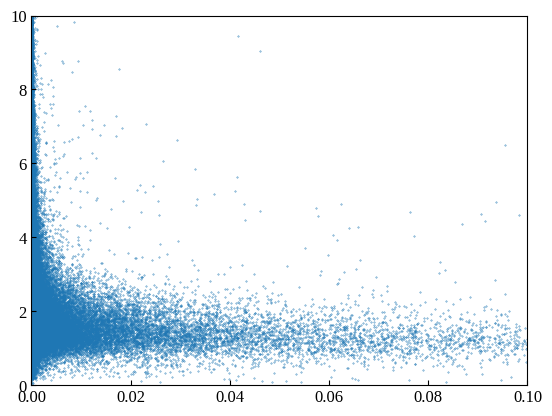

In [45]:
plt.scatter(result_font_TJ['cr'],result_font_TJ['spread'],s=0.1)
plt.ylim(0,10)
plt.xlim(0,0.1)

(0.0, 8.0)

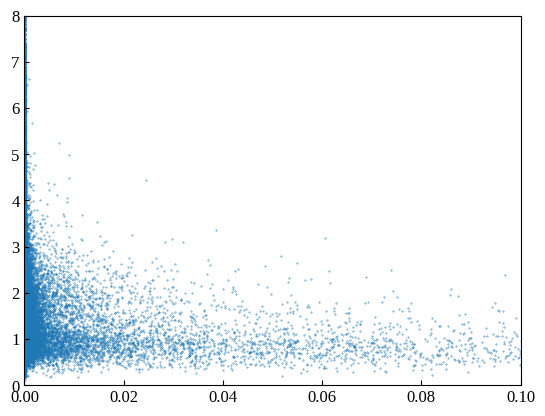

In [46]:
plt.scatter(result_font_FC['cr'],result_font_FC['spread'],s=0.1)
plt.xlim(0,0.1)
plt.ylim(0,8)

In [47]:
result_font['PTTC'].values

array([0., 0., 0., ..., 0., 0., 0.])

In [48]:
#result_font=pd.concat([result_font1,result_font2,result_font3])

In [49]:
result_font=result_font[result_font['v_ego']>0.0]

In [50]:
result_font=result_font[result_font['Distance']>2]

In [51]:
BIG_TTC = 10_000_000
EPS     = 1e-9

In [52]:
result_font['TTC_risk']=1/result_font['TTC']

In [53]:
result_font['tdtc'] = result_font['tdtc'].fillna(100000000)

In [54]:
result_font['ACT_risk']=1/result_font['ACT']

In [55]:
result_font['tdtc_risk']=1/abs(result_font['tdtc'])

In [56]:
result_font_3=result_font[result_font['v']<3]
result_font_6=result_font[(result_font['v']<6)&(result_font['v']>3)]
result_font_9=result_font[(result_font['v']>9)]

In [57]:
def filter_percentile(group,risk):
    lower = group[risk].quantile(0.001)
    upper = group[risk].quantile(0.999)
    return group[(group[risk] >= lower) & (group[risk] <= upper)]

def data_pre(angle_ranges,risk):
    """
    参数：
        angle_ranges: List of tuples，每个元素是(min_angle, max_angle)，支持一个或两个范围
                      例如 [(0, 45), (315, 360)] 或 [(90, 180)]
    返回：
        grouped_cr_mean: 含有筛选后平均TTC风险和角度信息的DataFrame
    """
    # 构建角度筛选条件
    condition = False
    for min_, max_ in angle_ranges:
        condition |= (result_font['drive_angle_degrees'] > min_) & (result_font['drive_angle_degrees'] < max_)
    # 应用条件过滤
    re_90 = result_font[condition].copy()

    # 坐标网格化
    re_90['near_x_int'] = re_90['near_x'] // 1
    re_90['near_y_int'] = re_90['near_y'] // 1
    # 分组后过滤极值
    filtered_df = re_90.groupby(['near_x_int', 'near_y_int'], group_keys=False).apply(lambda group: filter_percentile(group, risk))

    # 按网格求TTC均值
    grouped_cr_mean = filtered_df.groupby(['near_x_int', 'near_y_int'])[risk].mean().reset_index()

    # 计算极坐标信息
    grouped_cr_mean['Distance'] = np.sqrt(grouped_cr_mean['near_x_int']**2 + grouped_cr_mean['near_y_int']**2)
    x = grouped_cr_mean['near_x_int'].values
    y = grouped_cr_mean['near_y_int'].values
    angles_rad = (np.pi / 2 - np.arctan2(y, x)) % (2 * np.pi)
    angles_deg = np.degrees(angles_rad)
    grouped_cr_mean['angle_radians'] = angles_rad
    grouped_cr_mean['angle_degrees'] = angles_deg
    # 滤除异常值
    low, high = grouped_cr_mean[risk].quantile([0.01, 0.99])
    grouped_cr_mean = grouped_cr_mean[(grouped_cr_mean[risk] >= low) & (grouped_cr_mean[risk] <= high)]
    return grouped_cr_mean

In [58]:
all_=data_pre([(0,360)],'tdtc_risk')
par= data_pre([(0,10),(350,360)],'tdtc_risk')
mer1=data_pre([(10,80)],'tdtc_risk')#data_pre([(10,80), (280, 350)])
mer2=data_pre([(280, 350)],'tdtc_risk')#data_pre([(10,80), (280, 350)])
cro1=data_pre([(80,100)],'tdtc_risk')
cro2=data_pre([(260,280)],'tdtc_risk')

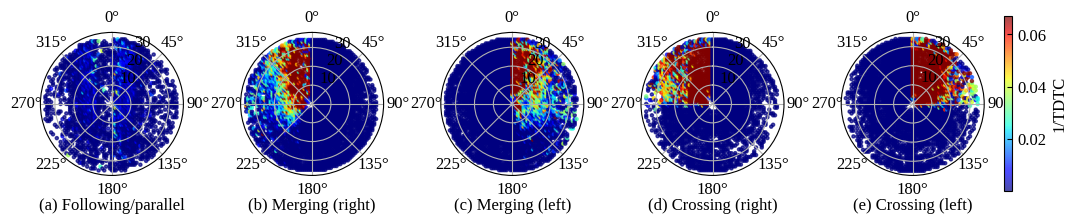

In [59]:
datasets = [par, mer1, mer2, cro1, cro2]
titles = [
    '(a) Following/parallel',
    '(b) Merging (right)',
    '(c) Merging (left)',
    '(d) Crossing (right)',
    '(e) Crossing (left)'
]

all_cr = np.concatenate([df['tdtc_risk'].values for df in datasets])
vmin, vmax = np.percentile(all_cr, [10, 90])

fig, axes = plt.subplots(
    1, 5,
    figsize=(12, 3),
    subplot_kw={'projection': 'polar'},
)
axes = axes.flatten()

sc = None
ticks = np.arange(0, 360, 45)

for ax, df, title in zip(axes, datasets, titles):
    sc = ax.scatter(
        df['angle_radians'],
        df['Distance'],
        c=df['tdtc_risk'],
        cmap='jet',
        vmin=vmin,
        vmax=vmax,
        s=5,
        alpha=0.7,
        marker='o'
    )
    ax.set_title(title, y=-0.3)
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)
    ax.set_xticks(np.deg2rad(ticks))

# ✅ 这里调子图之间的间距
# wspace 越大，子图之间横向间距越大；0.1~0.5 之间自己试一下
fig.subplots_adjust(
    left=0.05,   # 整个图离左边界的距离
    right=0.86,  # 给右边颜色柱留点空间
    top=0.95,
    bottom=0.15,
    wspace=0.4, # 子图之间的横向间距
    hspace=0.0   # 因为只有一行，这里随便
)

# 统一颜色柱
cbar = fig.colorbar(
    sc,
    ax=axes,
    orientation='vertical',
    fraction=0.009,   # 颜色条宽度
    pad=0.02         # 颜色条与子图组之间的距离
)
cbar.set_label('1/TDTC')
plt.savefig('/home/wangtao/下载/Trajectron-ped-veh/Data_ana/TDTC1.png', dpi=300,bbox_inches='tight', pad_inches=0)# 字体大小设为
plt.show()

In [60]:
all_=data_pre([(0,360)],'PTTC')
par= data_pre([(0,10),(350,360)],'PTTC')
mer1=data_pre([(10,80)],'PTTC')#data_pre([(10,80), (280, 350)])
mer2=data_pre([(280, 350)],'PTTC')#data_pre([(10,80), (280, 350)])
cro1=data_pre([(70,110)],'PTTC')
cro2=data_pre([(250,290)],'PTTC')

In [61]:
par = par.sort_values(by='PTTC', ascending=False).reset_index(drop=True)

In [62]:
par

,near_x_int,near_y_int,PTTC,Distance,angle_radians,angle_degrees
0,-14.0,15.0,0.125370,20.518285,5.532256,316.974934
1,-12.0,7.0,0.113636,13.892444,5.240463,300.256437
2,-11.0,10.0,0.111111,14.866069,5.450204,312.273689
3,2.0,14.0,0.104167,14.142136,0.141897,8.130102
4,-14.0,11.0,0.096154,17.804494,5.378358,308.157227
...,...,...,...,...,...,...
2710,-9.0,-4.0,0.000000,9.848858,4.294165,246.037511
2711,-9.0,-3.0,0.000000,9.486833,4.390638,251.565051
2712,-9.0,-2.0,0.000000,9.219544,4.493720,257.471192
2713,-9.0,-1.0,0.000000,9.055385,4.601732,263.659808


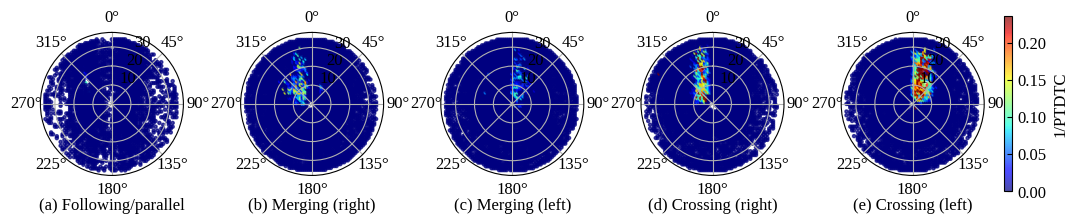

In [63]:
datasets = [par, mer1, mer2, cro1, cro2]
titles = [
    '(a) Following/parallel',
    '(b) Merging (right)',
    '(c) Merging (left)',
    '(d) Crossing (right)',
    '(e) Crossing (left)']
all_cr = np.concatenate([df['PTTC'].values for df in datasets])
vmin, vmax = np.percentile(all_cr, [1, 99])

fig, axes = plt.subplots(
    1, 5,
    figsize=(12, 3),
    subplot_kw={'projection': 'polar'},
)
axes = axes.flatten()

sc = None
ticks = np.arange(0, 360, 45)

for ax, df, title in zip(axes, datasets, titles):
    sc = ax.scatter(
        df['angle_radians'],
        df['Distance'],
        c=df['PTTC'],
        cmap='jet',
        vmin=vmin,
        vmax=vmax,
        s=5,
        alpha=0.7,
        marker='o'
    )
    ax.set_title(title, y=-0.3)
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)
    ax.set_xticks(np.deg2rad(ticks))

# ✅ 这里调子图之间的间距
# wspace 越大，子图之间横向间距越大；0.1~0.5 之间自己试一下
fig.subplots_adjust(
    left=0.05,   # 整个图离左边界的距离
    right=0.86,  # 给右边颜色柱留点空间
    top=0.95,
    bottom=0.15,
    wspace=0.4, # 子图之间的横向间距
    hspace=0.0
)
# 统一颜色柱
cbar = fig.colorbar(
    sc,
    ax=axes,
    orientation='vertical',
    fraction=0.009,   # 颜色条宽度
    pad=0.02         # 颜色条与子图组之间的距离
)
cbar.set_label('1/PTDTC')
plt.savefig('/home/wangtao/下载/Trajectron-ped-veh/Data_ana/PTTC.png', dpi=300,bbox_inches='tight', pad_inches=0)# 字体大小设为
plt.show()

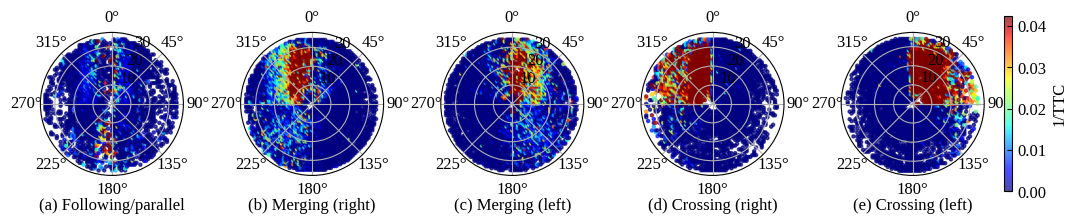

In [64]:
all_=data_pre([(0,360)],'TTC_risk')
par= data_pre([(0,10),(350,360)],'TTC_risk')
mer1=data_pre([(10,80)],'TTC_risk')#data_pre([(10,80), (280, 350)])
mer2=data_pre([(280, 350)],'TTC_risk')#data_pre([(10,80), (280, 350)])
cro1=data_pre([(80,100)],'TTC_risk')
cro2=data_pre([(260,280)],'TTC_risk')
datasets = [par, mer1, mer2, cro1, cro2]
titles = [
    '(a) Following/parallel',
    '(b) Merging (right)',
    '(c) Merging (left)',
    '(d) Crossing (right)',
    '(e) Crossing (left)'
]

all_cr = np.concatenate([df['TTC_risk'].values for df in datasets])
vmin, vmax = np.percentile(all_cr, [10, 90])

fig, axes = plt.subplots(
    1, 5,
    figsize=(12, 3),
    subplot_kw={'projection': 'polar'},
)
axes = axes.flatten()

sc = None
ticks = np.arange(0, 360, 45)

for ax, df, title in zip(axes, datasets, titles):
    sc = ax.scatter(
        df['angle_radians'],
        df['Distance'],
        c=df['TTC_risk'],
        cmap='jet',
        vmin=vmin,
        vmax=vmax,
        s=5,
        alpha=0.7,
        marker='o'
    )
    ax.set_title(title, y=-0.3)
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)
    ax.set_xticks(np.deg2rad(ticks))

# ✅ 这里调子图之间的间距
# wspace 越大，子图之间横向间距越大；0.1~0.5 之间自己试一下
fig.subplots_adjust(
    left=0.05,   # 整个图离左边界的距离
    right=0.86,  # 给右边颜色柱留点空间
    top=0.95,
    bottom=0.15,
    wspace=0.4, # 子图之间的横向间距
    hspace=0.0   # 因为只有一行，这里随便
)

# 统一颜色柱
cbar = fig.colorbar(
    sc,
    ax=axes,
    orientation='vertical',
    fraction=0.009,   # 颜色条宽度
    pad=0.02         # 颜色条与子图组之间的距离
)
cbar.set_label('1/TTC')
plt.savefig('/home/wangtao/下载/Trajectron-ped-veh/Data_ana/TTC1.png', dpi=300,bbox_inches='tight', pad_inches=0)# 字体大小设为
plt.show()

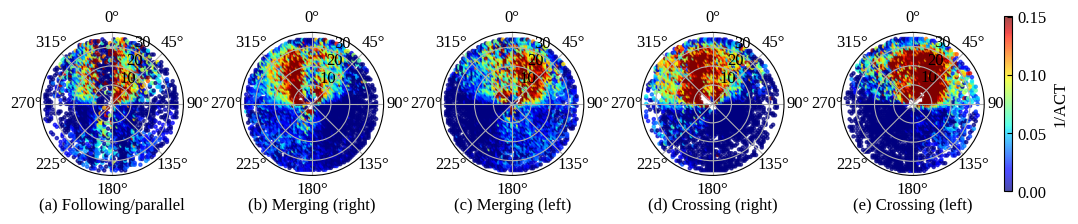

In [65]:
all_=data_pre([(0,360)],'ACT_risk')
par= data_pre([(0,10),(350,360)],'ACT_risk')
mer1=data_pre([(10,80)],'ACT_risk')#data_pre([(10,80), (280, 350)])
mer2=data_pre([(280, 350)],'ACT_risk')#data_pre([(10,80), (280, 350)])
cro1=data_pre([(80,100)],'ACT_risk')
cro2=data_pre([(260,280)],'ACT_risk')
# 1️⃣ 数据准备
datasets = [par, mer1, mer2, cro1, cro2]
titles = [
    '(a) Following/parallel',
    '(b) Merging (right)',
    '(c) Merging (left)',
    '(d) Crossing (right)',
    '(e) Crossing (left)'
]

all_cr = np.concatenate([df['ACT_risk'].values for df in datasets])
vmin, vmax = np.percentile(all_cr, [10, 90])

fig, axes = plt.subplots(
    1, 5,
    figsize=(12, 3),
    subplot_kw={'projection': 'polar'},
)
axes = axes.flatten()

sc = None
ticks = np.arange(0, 360, 45)

for ax, df, title in zip(axes, datasets, titles):
    sc = ax.scatter(
        df['angle_radians'],
        df['Distance'],
        c=df['ACT_risk'],
        cmap='jet',
        vmin=vmin,
        vmax=vmax,
        s=5,
        alpha=0.7,
        marker='o'
    )
    ax.set_title(title, y=-0.3)
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)
    ax.set_xticks(np.deg2rad(ticks))

# ✅ 这里调子图之间的间距
# wspace 越大，子图之间横向间距越大；0.1~0.5 之间自己试一下
fig.subplots_adjust(
    left=0.05,   # 整个图离左边界的距离
    right=0.86,  # 给右边颜色柱留点空间
    top=0.95,
    bottom=0.15,
    wspace=0.4, # 子图之间的横向间距
    hspace=0.0   # 因为只有一行，这里随便
)

# 统一颜色柱
cbar = fig.colorbar(
    sc,
    ax=axes,
    orientation='vertical',
    fraction=0.009,   # 颜色条宽度
    pad=0.02         # 颜色条与子图组之间的距离
)
cbar.set_label('1/ACT')
plt.savefig('/home/wangtao/下载/Trajectron-ped-veh/Data_ana/ACT1.png', dpi=300,bbox_inches='tight', pad_inches=0)# 字体大小设为
plt.show()

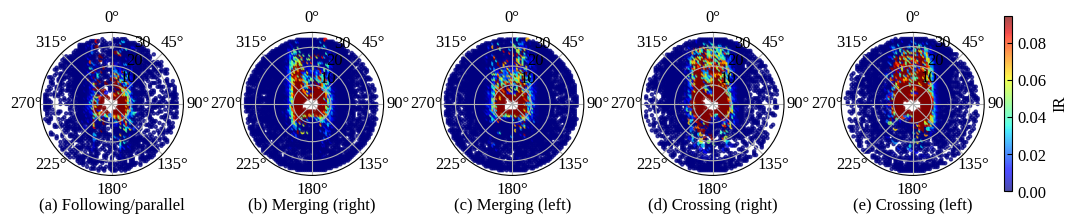

In [66]:
all_=data_pre([(0,360)],'VPIR')
par= data_pre([(0,10),(350,360)],'VPIR')
mer1=data_pre([(10,80)],'VPIR')#data_pre([(10,80), (280, 350)])
mer2=data_pre([(280, 350)],'VPIR')#data_pre([(10,80), (280, 350)])
cro1=data_pre([(80,100)],'VPIR')
cro2=data_pre([(260,280)],'VPIR')
# 1️⃣ 数据准备
#titles = ['(a) All interaction', '(b) Parallel interaction', '(c) Merging interaction (right)', '(d) Merging interaction (left)', '(d) Crossing interaction (right)','(e) Crossing interaction (left)']
datasets = [par, mer1, mer2, cro1, cro2]
titles = [
    '(a) Following/parallel',
    '(b) Merging (right)',
    '(c) Merging (left)',
    '(d) Crossing (right)',
    '(e) Crossing (left)'
]

all_cr = np.concatenate([df['VPIR'].values for df in datasets])
vmin, vmax = np.percentile(all_cr, [10, 90])

fig, axes = plt.subplots(
    1, 5,
    figsize=(12, 3),
    subplot_kw={'projection': 'polar'},
)
axes = axes.flatten()

sc = None
ticks = np.arange(0, 360, 45)

for ax, df, title in zip(axes, datasets, titles):
    sc = ax.scatter(
        df['angle_radians'],
        df['Distance'],
        c=df['VPIR'],
        cmap='jet',
        vmin=vmin,
        vmax=vmax,
        s=5,
        alpha=0.7,
        marker='o'
    )
    ax.set_title(title, y=-0.3)
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)
    ax.set_xticks(np.deg2rad(ticks))

# ✅ 这里调子图之间的间距
# wspace 越大，子图之间横向间距越大；0.1~0.5 之间自己试一下
fig.subplots_adjust(
    left=0.05,   # 整个图离左边界的距离
    right=0.86,  # 给右边颜色柱留点空间
    top=0.95,
    bottom=0.15,
    wspace=0.4, # 子图之间的横向间距
    hspace=0.0   # 因为只有一行，这里随便
)

# 统一颜色柱
cbar = fig.colorbar(
    sc,
    ax=axes,
    orientation='vertical',
    fraction=0.009,   # 颜色条宽度
    pad=0.02         # 颜色条与子图组之间的距离
)
cbar.set_label('IR')
plt.savefig('/home/wangtao/下载/Trajectron-ped-veh/Data_ana/VPIR1.png', dpi=300,bbox_inches='tight', pad_inches=0)# 字体大小设为
plt.show()

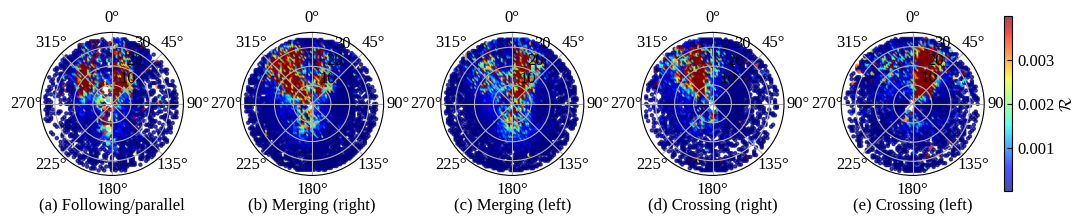

In [67]:
all_=data_pre([(0,360)],'cr')
par= data_pre([(0,10),(350,360)],'cr')
mer1=data_pre([(10,80)],'cr')#data_pre([(10,80), (280, 350)])
mer2=data_pre([(280, 350)],'cr')#data_pre([(10,80), (280, 350)])
cro1=data_pre([(80,100)],'cr')
cro2=data_pre([(260,280)],'cr')
# 1️⃣ 数据准备
#titles = ['(a) All interaction', '(b) Parallel interaction', '(c) Merging interaction (right)', '(d) Merging interaction (left)', '(d) Crossing interaction (right)','(e) Crossing interaction (left)']
datasets = [par, mer1, mer2, cro1, cro2]
titles = [
    '(a) Following/parallel',
    '(b) Merging (right)',
    '(c) Merging (left)',
    '(d) Crossing (right)',
    '(e) Crossing (left)'
]

all_cr = np.concatenate([df['cr'].values for df in datasets])
vmin, vmax = np.percentile(all_cr, [10, 90])

fig, axes = plt.subplots(
    1, 5,
    figsize=(12, 3),
    subplot_kw={'projection': 'polar'},
)
axes = axes.flatten()

sc = None
ticks = np.arange(0, 360, 45)

for ax, df, title in zip(axes, datasets, titles):
    sc = ax.scatter(
        df['angle_radians'],
        df['Distance'],
        c=df['cr'],
        cmap='jet',
        vmin=vmin,
        vmax=vmax,
        s=5,
        alpha=0.7,
        marker='o'
    )
    ax.set_title(title, y=-0.3)
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)
    ax.set_xticks(np.deg2rad(ticks))

# ✅ 这里调子图之间的间距
# wspace 越大，子图之间横向间距越大；0.1~0.5 之间自己试一下
fig.subplots_adjust(
    left=0.05,   # 整个图离左边界的距离
    right=0.86,  # 给右边颜色柱留点空间
    top=0.95,
    bottom=0.15,
    wspace=0.4, # 子图之间的横向间距
    hspace=0.0   # 因为只有一行，这里随便
)

# 统一颜色柱
cbar = fig.colorbar(
    sc,
    ax=axes,
    orientation='vertical',
    fraction=0.009,   # 颜色条宽度
    pad=0.02         # 颜色条与子图组之间的距离
)
cbar.set_label(r'$\mathcal{R}$')
plt.savefig('/home/wangtao/下载/Trajectron-ped-veh/Data_ana/cr1.png', dpi=300,bbox_inches='tight', pad_inches=0)# 字体大小设为
plt.show()

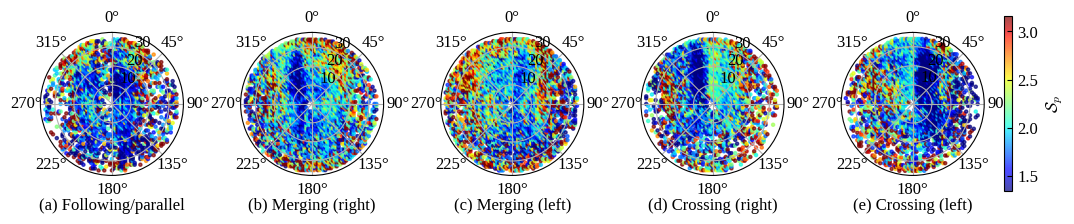

In [68]:
all_=data_pre([(0,360)],'spread')
par= data_pre([(0,10),(350,360)],'spread')
mer1=data_pre([(10,80)],'spread')#data_pre([(10,80), (280, 350)])
mer2=data_pre([(280, 350)],'spread')#data_pre([(10,80), (280, 350)])
cro1=data_pre([(80,100)],'spread')
cro2=data_pre([(260,280)],'spread')
#titles = ['(a) All interaction', '(b) Parallel interaction', '(c) Merging interaction (right)', '(d) Merging interaction (left)', '(d) Crossing interaction (right)','(e) Crossing interaction (left)']
datasets = [par, mer1, mer2, cro1, cro2]
titles = [
    '(a) Following/parallel',
    '(b) Merging (right)',
    '(c) Merging (left)',
    '(d) Crossing (right)',
    '(e) Crossing (left)']
all_cr = np.concatenate([df['spread'].values for df in datasets])
vmin, vmax = np.percentile(all_cr, [10,90])
fig, axes = plt.subplots(
    1, 5,
    figsize=(12, 3),
    subplot_kw={'projection': 'polar'},)
axes = axes.flatten()
sc = None
ticks = np.arange(0, 360, 45)
for ax, df, title in zip(axes, datasets, titles):
    sc = ax.scatter(
        df['angle_radians'],
        df['Distance'],
        c=df['spread'],
        cmap='jet',
        vmin=vmin,
        vmax=vmax,
        s=5,
        alpha=0.7,
        marker='o')
    ax.set_title(title, y=-0.3)
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)
    ax.set_xticks(np.deg2rad(ticks))
# ✅ 这里调子图之间的间距
# wspace 越大，子图之间横向间距越大；0.1~0.5 之间自己试一下
fig.subplots_adjust(
    left=0.05,   # 整个图离左边界的距离
    right=0.86,  # 给右边颜色柱留点空间
    top=0.95,
    bottom=0.15,
    wspace=0.4, # 子图之间的横向间距
    hspace=0.0)
cbar = fig.colorbar(
    sc,
    ax=axes,
    orientation='vertical',
    fraction=0.009,   # 颜色条宽度
    pad=0.02         # 颜色条与子图组之间的距离
)
cbar.set_label(r'$\mathcal{S}_{p}$')
plt.savefig('/home/wangtao/下载/Trajectron-ped-veh/Data_ana/entropy.png', dpi=300,bbox_inches='tight', pad_inches=0)# 字体大小设为
plt.show()